In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf


Type samples:  <class 'numpy.ndarray'>
Samples shape:  (1321967,)
Example shape  (1321967,) Sample rate  44100 Data type <class 'numpy.ndarray'>


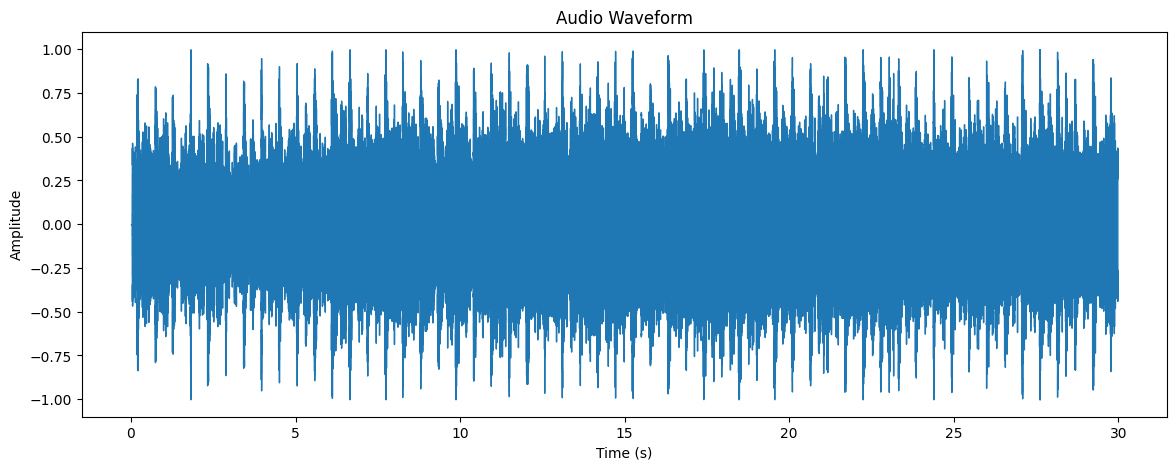

In [2]:
# Load the audio file
AUDIO_FILE_NP = './data/mels/0-of-15/2_Freeway_KurtVile.npy'
AUDIO_FILE_WF = './data/waveforms/0-of-15/2_Freeway_KurtVile.wav'
samples, sample_rate = librosa.load(AUDIO_FILE_WF, sr=None)
print("Type samples: ", type(samples))
print("Samples shape: ", samples.shape)

# x-axis has been converted to time using our sample rate. 
# matplotlib plt.plot(y), would output the same figure, but with sample 
# number on the x-axis instead of seconds
plt.figure(figsize=(14, 5))
librosa.display.waveshow(samples, sr=sample_rate)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
print ('Example shape ', samples.shape, 'Sample rate ', sample_rate, 'Data type', type(samples))

In [4]:
from IPython.display import Audio
Audio(AUDIO_FILE_WF)

### Convert from .npy log mel spectrogram in db back to waveform

In [3]:
#load log-mel spectrogram which is in decibels
mel_db = np.load(AUDIO_FILE_NP)

print(mel_db.shape)
print(mel_db.min(), mel_db.max())
print(mel_db)

(80, 862)
-11.110932 1.4041871
[[-10.112214   -5.3531213  -4.156722  ...  -1.4669412  -1.7993697
   -1.8495413]
 [ -9.487379   -4.5584517  -2.8844047 ...  -2.1016085  -2.1114907
   -1.9990536]
 [ -9.098792   -3.9730875  -2.8279896 ...  -1.4784824  -1.0625372
   -1.4387659]
 ...
 [-11.110932   -5.382495   -4.107481  ...  -4.1451855  -4.4527345
   -4.3945208]
 [-10.418916   -5.63361    -4.154458  ...  -4.5273643  -4.711195
   -4.674621 ]
 [-10.091424   -6.134171   -4.4488993 ...  -4.8342667  -4.8710446
   -5.0127964]]


In [4]:
#convert npy mel spectrogram back to waveform
mel_power = librosa.db_to_power(mel_db) #undo power to db

audio = librosa.feature.inverse.mel_to_audio(mel_power,
                                             sr=22050,
                                             n_fft=2048,
                                             hop_length=512,
                                             power=2.0,
                                             n_iter=128,
                                             win_length=2048
                                             )
audio = audio / np.max(np.abs(audio))
sf.write("reconstructed.wav", audio, 22050)

Example shape  (1321472,) Sample rate  22050 Data type <class 'numpy.ndarray'>


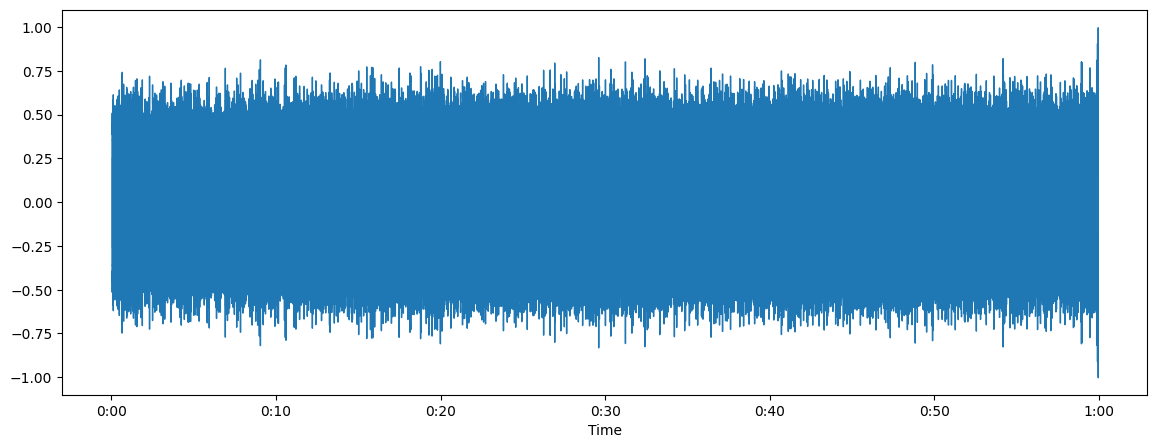

In [5]:
samples_rc, sample_rate_rc = librosa.load('reconstructed.wav', sr=None)

plt.figure(figsize=(14, 5))
librosa.display.waveshow(samples_rc, sr=sample_rate_rc)
print ('Example shape ', samples_rc.shape, 'Sample rate ', sample_rate_rc, 'Data type', type(samples_rc))

In [24]:
Audio('reconstructed.wav')

C:\Users\justi\AppData\Local\Temp\ipykernel_14536\2680270098.py:2: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(sgram)


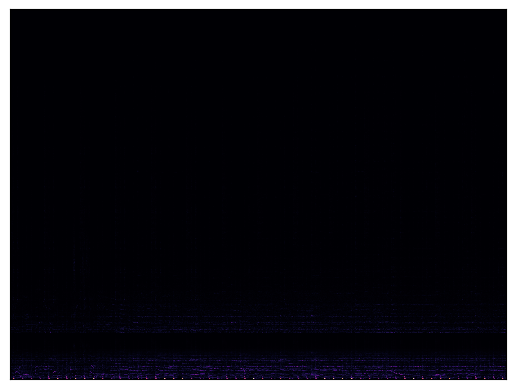

In [6]:
sgram = librosa.stft(samples)
librosa.display.specshow(sgram)
# use the mel-scale instead of raw frequency
sgram_mag, _ = librosa.magphase(sgram)
mel_scale_sgram = librosa.feature.melspectrogram(S=sgram_mag, sr=sample_rate)
librosa.display.specshow(mel_scale_sgram)

(128, 2582)


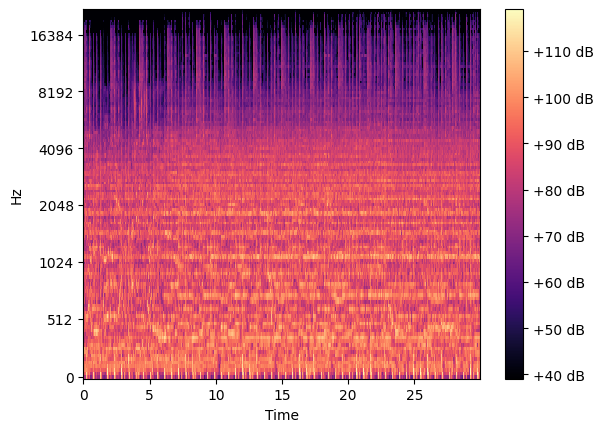

In [7]:

# use the decibel scale to get the final Mel Spectrogram
mel_sgram = librosa.amplitude_to_db(mel_scale_sgram, ref=np.min)
print(mel_sgram.shape)
librosa.display.specshow(mel_sgram, sr=sample_rate, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

In [7]:
print(type(mel_sgram))
print(mel_sgram)
print(mel_sgram.shape)


<class 'numpy.ndarray'>
[[ 42.00863   42.00863   65.27037  ...  92.85984   92.61162   97.45567 ]
 [ 42.00863   46.698868  63.294273 ... 104.19295  102.84597  100.15493 ]
 [ 42.00863   57.421654  67.40615  ...  98.52238   99.595856  98.19293 ]
 ...
 [ 42.00863   42.00863   42.00863  ...  42.00863   42.00863   42.00863 ]
 [ 42.00863   42.00863   42.00863  ...  42.00863   42.00863   42.00863 ]
 [ 42.00863   42.00863   42.00863  ...  42.00863   42.00863   42.00863 ]]
(128, 2582)


In [8]:
import torch
import numpy

mel = np.load("data/mels/0-of-15/0_Food_AWOL.npy")
mel = torch.from_numpy(mel)
print(type(mel))
print(mel.shape)
print(mel)



<class 'torch.Tensor'>
torch.Size([80, 2582])
tensor([[ -8.6664,  -7.4227,  -4.7031,  ...,  -0.9528,  -1.0260,  -0.7980],
        [ -8.5571,  -6.3789,  -4.8992,  ...,  -0.4022,  -0.5111,  -0.9151],
        [ -8.4585,  -4.7056,  -3.9112,  ...,  -1.0098,  -0.6900,  -0.6092],
        ...,
        [-11.5129,  -7.5352,  -6.1133,  ...,  -3.4479,  -3.1685,  -3.1475],
        [-11.5129,  -7.3061,  -6.0562,  ...,  -3.4089,  -3.5845,  -3.6523],
        [-11.5129,  -7.7992,  -6.3638,  ...,  -3.2335,  -3.0085,  -3.3107]])
